<hr/>
<h1>6. Clustering</h1>

<p>I will be proceeding to conduct the clustering for my Dataset. In this section, I will primarily be using 3 different methods of clustering and subsequently cross referring the results to each other. Afterwards, I will fine tune each of the Clustering Models to determine the most ideal and suitable model to utlise for my dataset. The models that I will be utilising are indicated below.</p>
<br/>
<p><strong><u>K-Means (Centroid Based)</u></strong></p>
<ul>
    <li>Purpose: Partitions Data into k clusters, aiming to minimise intra-cluster variance (WCSS - Within-Cluster Sum of Squares) and best for well-separated data.</li>
</ul>
<p><strong><u>Agglomerative Clustering (Hierarchical Clustering)</u></strong></p>
<ul>
    <li>Purpose: Recursively merges data points into a Hierarchical Tree (Dendrogram). It does not require k beforehand and is best suited for nested or hierarchical structures.</li>
</ul>
<p><strong><u>DBSCAN (Density-Based Spatial Clustering of Applications with Noise)</u></strong></p>
<ul>
    <li>Purpose: Groups data points based on density and does not require specifying k and is ideal for detecting arbitrary-shaped clusters.</li>
</ul>
<br/>
<p>With the models listed, I will proceed to utilise each of the model in the cells below.</p>

<hr/>
<h2>6.1 K-Means (Centroid Based)</h2>

<p>K-Means is a centroid-based clustering algorithm that partitions data into k clusters, aiming to minimise intra-cluster variance (WCSS - Within-Cluster Sum of Squares). It is best for well-separated, spherical clusters. I have listed the strengths and weaknesses of K-Means below.</p>
<br/>
<span style="color:green"><p><strong><u>Strengths</u></strong></p></span>
<ul>
    <li>Fast & Scalable</li>
    <li>Easy Implementation & Interpretation</li>
    <li>Works Well With Spherical Clusters</li>
    <li>Able To Handle High Dimension Data</li>
</ul>
<span style="color:red"><p><strong><u>Weaknesses</u></strong></p></span>
<ul>
    <li>k Needs To Be Predefined</li>
    <li>Sensitive To Outliers</li>
    <li>Struggles With Non-Speherical Clusters</li>
    <li>Sensitive To Initialisation</li>
</ul>
<br/>
<p>With the context of the Strengths and Weaknesses of K-Means in mind, I will proceed to find the optimal k-cluster in the next sub-section.</p>

<hr/>
<h3>6.1.1 Deciding Best Scaling For K-Means</h3>

<p>I conducted 2 methods of Scaling previously which are the Z-Score Standardisation and the Min-Max Scaling. These 2 methods utilised different methods of adjusting the Numerical Value which was stated previosuly. I will be comparing the WCSS and Silhouette Score of the Min-Max Scaling Data and the Z-Score Standardisation Data. The formula for WCSS and Silhouette Score have been indicated below.</p>

$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
$$

**Where:**  
- $k$ → Number of clusters  
- $C_i$ → Cluster $i$  
- $x$ → Data point in cluster $C_i$  
- $\mu_i$ → Centroid of cluster $C_i$  
- $||x - \mu_i||^2$ → Squared Euclidean distance between each data point and its cluster centroid  

$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

**Where:**  
- $S(i)$ → Silhouette Score of point $i$  
- $a(i)$ → Average distance between point $i$ and other points in the same cluster  
- $b(i)$ → Average distance between point $i$ and the nearest neighboring cluster  
- $-1 \leq S(i) \leq 1$, where:  
  - $S(i)$ close to **1** → Well clustered  
  - $S(i)$ close to **0** → Overlapping clusters  
  - $S(i)$ close to **-1** → Incorrect clustering
 
<br/>
<p>With the formula listed, I will proceed to plot out the Graphs to identify the Best Scaling Method to use for K-Means.</p>

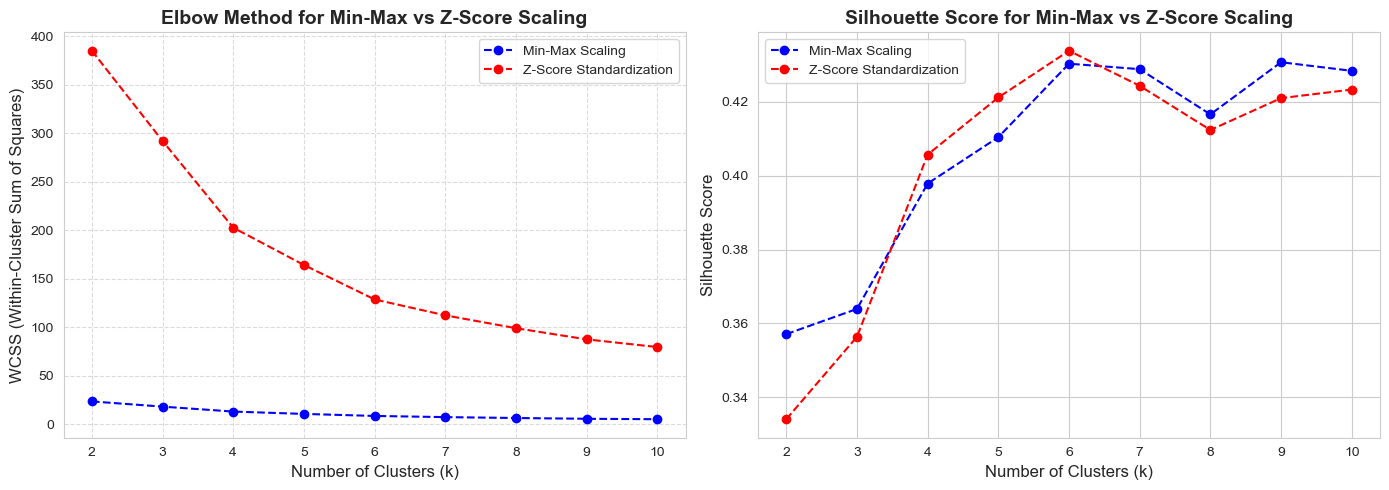

In [124]:
# ---------- Defining Range Of K-Clusters ----------- #
k_values = range(2, 11)

# ---------- Initiate List To Store Results ----------- #
wcss_minmax, silhouette_scores_minmax = [], []
wcss_zscore, silhouette_scores_zscore = [], []

# ----------- Computing Cluster Metrics ----------- #
for k in k_values:
    # K-Means On Min-Max Scaled Data #
    kmeans_minmax = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels_minmax = kmeans_minmax.fit_predict(df_minmax[features_to_scale])
    wcss_minmax.append(kmeans_minmax.inertia_)
    silhouette_scores_minmax.append(silhouette_score(df_minmax[features_to_scale], cluster_labels_minmax))

    # K-Means On Z-Score Standardized Data #
    kmeans_zscore = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels_zscore = kmeans_zscore.fit_predict(df_zscore[features_to_scale])
    wcss_zscore.append(kmeans_zscore.inertia_)
    silhouette_scores_zscore.append(silhouette_score(df_zscore[features_to_scale], cluster_labels_zscore))

# ----------- Defining Subplots ----------- #
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------ Elbow Method For WCSS Comparison ----------- #
axes[0].plot(k_values, wcss_minmax, marker='o', linestyle='--', color='b', label="Min-Max Scaling")
axes[0].plot(k_values, wcss_zscore, marker='o', linestyle='--', color='r', label="Z-Score Standardization")
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method for Min-Max vs Z-Score Scaling', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, which="both", linestyle="--", alpha=0.7)

# ----------- Silhouette Scores Comparison ----------- #
axes[1].plot(k_values, silhouette_scores_minmax, marker='o', linestyle='--', color='b', label="Min-Max Scaling")
axes[1].plot(k_values, silhouette_scores_zscore, marker='o', linestyle='--', color='r', label="Z-Score Standardization")
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Min-Max vs Z-Score Scaling', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True)

# ------------ Displaying Plot ----------- #
plt.tight_layout()
plt.show()

<p>With reference to the output to the Line Plot for the WCSS and the Silhouette Score, I am able to see that Min-Max Scaling has a lower WCSS while Z-Score Standardisation has a higher WCSS. For the Silhouette Score, I am able to see that the Min-Max has a lower Silhouette Score compared to Z-Score Standardisation. The observations and conclusion are listed below.</p>
<br/>
<p><strong><u>Min-Max Scaling</u></strong></p>
<ul>
    <li>Within Cluster Sum of Squares: Min-Max Scaling has a very low WCSS at around 25.</li>
    <li>Silhouette Score: Min-Max Scaling has a moderate Silhouette Score, peaking at 0.42 for 6 Clusters.</li>
</ul>
<p><strong><u>Z-Score Standardisation</u></strong></p>
<ul>
    <li>Within Cluster Sum of Squares: Z-Score Standardisation has a relatively higher WCSS between 400 and 90.</li>
    <li>Silhouette Score: Z-Score Standardisation has a higher Silhouette Score, peaking at 0.43 for 6 Clusters.</li>
</ul>
<p><strong><u>Conclusion</u></strong></p>
<ul>
    <li>Scaling Method To Use: Z-Score Standardisation.</li>
    <li>Reason: Performed better in Silhouette Score than Min-Max Scaling.</li>
</ul>
<p>With the observation and conclusion listed out, I will proceed to find the Optimal K-Clusters and Compare the PCA results with the Original Data.</p>

<hr/>
<h3>6.1.2 Finding Optimal K-Clusters And Reducing Dimensions</h3>

<p>As K-Means required a k-cluser to be predefined, I will be utilising the Elbow Method and Sillhouette Score to find the Optimal k. The reason for utilising 2 methods is such that should one of the method fail, there will be another method to fallback on. It will also provide a cross reference so as to confirm the Optimal K-Clusters based on different metrics. The computation for the WCSS and Sillhouette Score are indcated below. I will also be using Principal Component Analysis to reduce the dimensions of the Data to compare the results and determine if it improves the Silhouette Score. The formula for PCA is also indicated below.</p>
<br/>

$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
$$

**Where:**  
- $k$ → Number of clusters  
- $C_i$ → Cluster $i$  
- $x$ → Data point in cluster $C_i$  
- $\mu_i$ → Centroid of cluster $C_i$  
- $||x - \mu_i||^2$ → Squared Euclidean distance between each data point and its cluster centroid  

$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

**Where:**  
- $S(i)$ → Silhouette Score of point $i$  
- $a(i)$ → Average distance between point $i$ and other points in the same cluster  
- $b(i)$ → Average distance between point $i$ and the nearest neighboring cluster  
- $-1 \leq S(i) \leq 1$, where:  
  - $S(i)$ close to **1** → Well clustered  
  - $S(i)$ close to **0** → Overlapping clusters  
  - $S(i)$ close to **-1** → Incorrect clustering

$$
Z = X W
$$

**Where:**
- $ Z $ is the transformed data in the new principal component space.  
- $ X $ is the original data matrix (centered by subtracting the mean).  
- $ W $ is the matrix of eigenvectors (principal components).  

$$
C = \frac{1}{n} X^T X
$$

**Where:**
- $ C $ is the covariance matrix of $ X $.  
- $ n $ is the number of samples.  

$$
C W = \lambda W
$$

**Where:**

- $ \lambda $ are the eigenvalues.  
- $ W $ are the corresponding eigenvectors (principal components).  
<br/>
<p>With the formulas listed, I will proceed to plot the Line Graph and conduct PCA in the cell below so as to identify the optimal K-Cluster.</p>

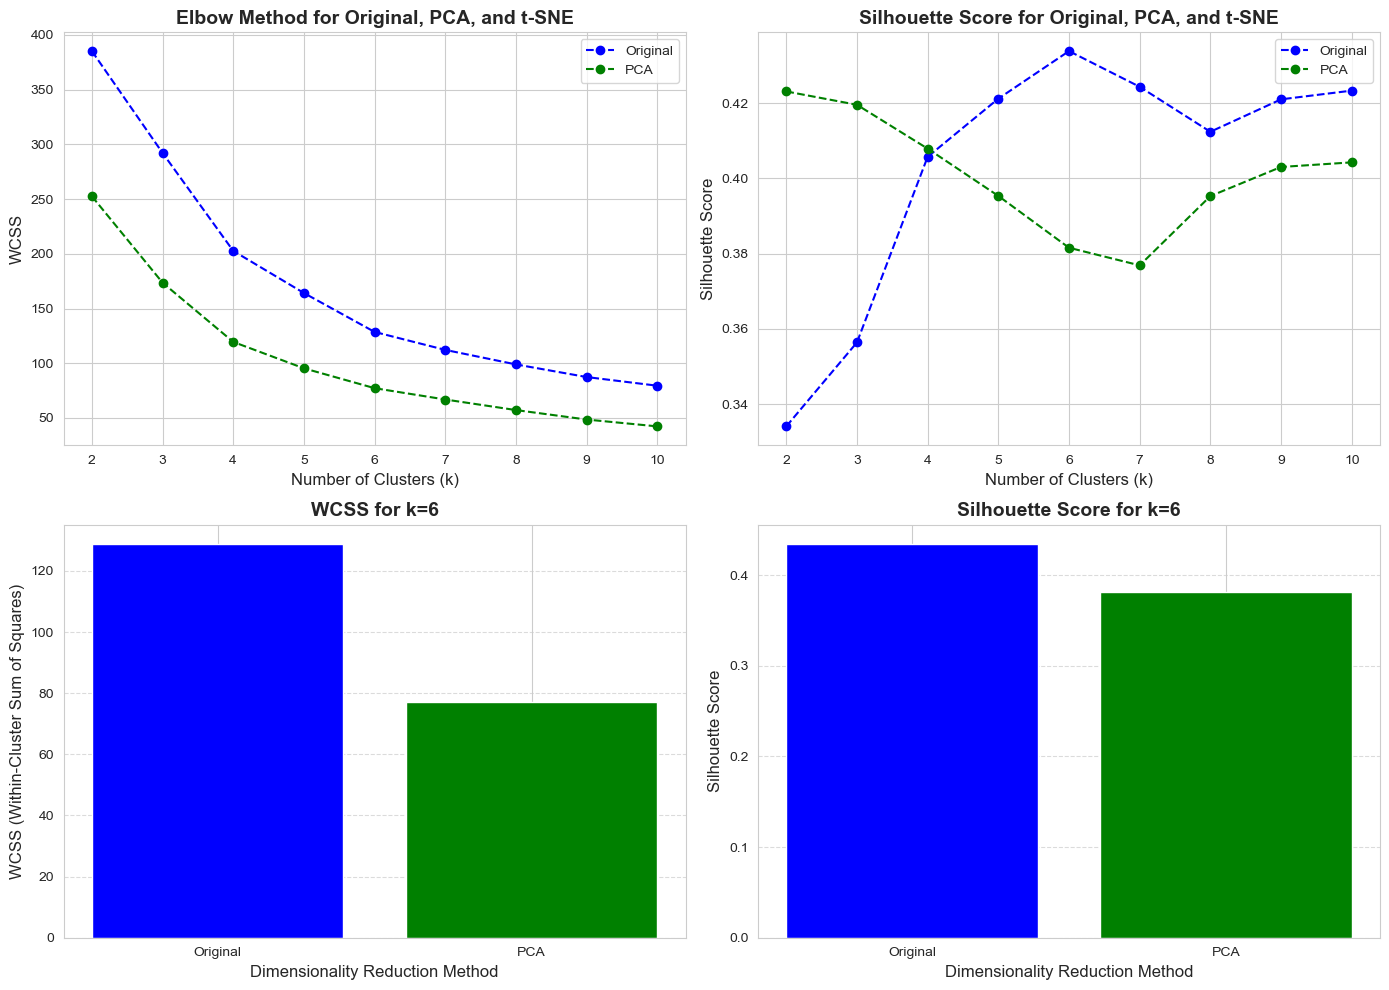

In [128]:
# ---------- Defining Range Of K-Clusters ----------- #
k_values = range(2, 11)

# ----------- Applying PCA ----------- #
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore[features_to_scale])

# ---------- Initiate List To Store Results ----------- #
wcss_original, silhouette_scores_original = [], []
wcss_pca, silhouette_scores_pca = [], []

# ----------- Computing Cluster Metrics ----------- #
for k in k_values:
    # K-Means On Original Data #
    kmeans_original = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels_original = kmeans_original.fit_predict(df_zscore[features_to_scale])
    wcss_original.append(kmeans_original.inertia_)
    silhouette_scores_original.append(silhouette_score(df_zscore[features_to_scale], cluster_labels_original))

    # K-Means On PCA Data #
    kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels_pca = kmeans_pca.fit_predict(pca_result)
    wcss_pca.append(kmeans_pca.inertia_)
    silhouette_scores_pca.append(silhouette_score(pca_result, cluster_labels_pca))

# ----------- Defining Subplots ----------- #
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------------ Elbow Method For WCSS Comparison ----------- #
axes[0, 0].plot(k_values, wcss_original, marker='o', linestyle='--', color='blue', label="Original")
axes[0, 0].plot(k_values, wcss_pca, marker='o', linestyle='--', color='green', label="PCA")
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('WCSS', fontsize=12)
axes[0, 0].set_title('Elbow Method for Original, PCA, and t-SNE', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True)

# ----------- Silhouette Scores Comparison ----------- #
axes[0, 1].plot(k_values, silhouette_scores_original, marker='o', linestyle='--', color='blue', label="Original")
axes[0, 1].plot(k_values, silhouette_scores_pca, marker='o', linestyle='--', color='green', label="PCA")
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score for Original and PCA', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True)

# ------------ WCSS Bar Plot For Best k ----------- #
best_k = 6
axes[1, 0].bar(['Original', 'PCA'], [wcss_original[best_k-2], wcss_pca[best_k-2]], color=['blue', 'green'])
axes[1, 0].set_xlabel('Dimensionality Reduction Method', fontsize=12)
axes[1, 0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
axes[1, 0].set_title(f'WCSS for k={best_k}', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# ------------ Silhouette Scores Bar Plot For Best k ----------- #
axes[1, 1].bar(['Original', 'PCA'], [silhouette_scores_original[best_k-2], silhouette_scores_pca[best_k-2]], color=['blue', 'green'])
axes[1, 1].set_xlabel('Dimensionality Reduction Method', fontsize=12)
axes[1, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[1, 1].set_title(f'Silhouette Score for k={best_k}', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

<p>With reference to the output of the Line Graph showing the Elbow Method and Silhouette Score for the Optimal k, I am able to come to the conclusion that the Optimal K is 6. The observation for each of the method respectively have been indicated below.</p>
<br/>
<p><strong><u>Elbow Method</u></strong></p>
<ul>
    <li>At k = 6, the rate of WCSS decrease slows down.</li>
</ul>
<p><strong><u>Sihouette Method</u></strong></p>
<ul>
    <li>At k = 6, the Silhoutte Score peaked the highest at around 0.46.</li>
</ul>
<p><strong><u>Dimension Reduction</u></strong></p>
<ul>
    <li>Use Orginal Data due to higher Silhouette Score.</li>
</ul>
<br/>
<p>Therefore, with the observations laid out and the ideal cluster of 6 determined, I will proceed to clustering using K-Means.</p>

<hr/>
<h3>6.1.3 Visualising Clusters Using t-SNE</h3>

<p>After finding the Optimal k-Cluster, I will proceed to visualise the Clusters by reducing the Dimensions using t-SNE and subsequently using a Scatterplot to viusalise the 6 Clusters. t-SNE allows us to reduce the dimensions into 2 dimensions to allow for a better visualisation. The formula for t-SNE is indicated below.</p>

The probability distribution in high-dimensional space is defined as:

$$ P_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)} $$

Where:

- $ P_{j|i} $ is the conditional probability that point $ x_j $ is chosen as a neighbor of point $ x_i $.  
- $ x_i, x_j $ are high-dimensional data points.  
- $ \sigma_i $ is the bandwidth of the Gaussian kernel for point $ x_i $.  

The probability distribution in low-dimensional space is:

$$ Q_{j|i} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq i} (1 + ||y_i - y_k||^2)^{-1}} $$

Where:

- $ Q_{j|i} $ is the conditional probability in the lower-dimensional space.  
- $ y_i, y_j $ are the mapped points in the lower-dimensional space.  

The Kullback-Leibler (KL) divergence, which t-SNE minimizes, is given by:

$$ KL(P||Q) = \sum_i \sum_j P_{ij} \log \frac{P_{ij}}{Q_{ij}} $$

Where:

- $ KL(P||Q) $ measures the difference between the high-dimensional and low-dimensional distributions.  
- $ P_{ij} $ and $ Q_{ij} 
- $ are the symmetric joint probabilities.  

<br/>
<p>With the formula indicated, I will proceed to conduct the visualisation in the cell below.</p>

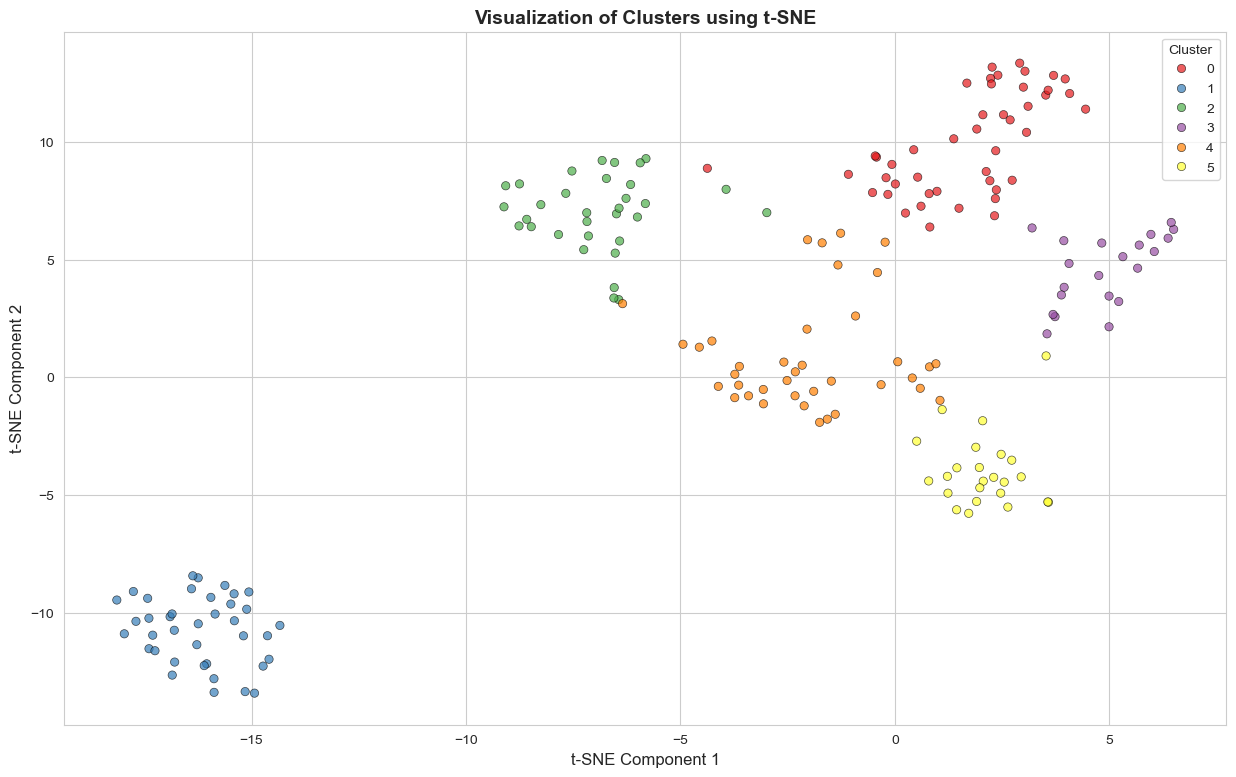

In [132]:
# ----------- Defining Optimal K-Clusters ------------ #
optimal_k = 6

# ------------- Applying K-Means On Scaled Data ------------ #
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_zscore['Cluster'] = kmeans.fit_predict(df_zscore[features_to_scale])

# ----------- Extracting Cluster Centers ------------ #
cluster_centers = kmeans.cluster_centers_

# -------------- Applying t-SNE For Visualisation ------------- #
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
tsne_results = tsne.fit_transform(df_zscore[features_to_scale])

# ------------ Adding t-SNE Results Into DataFrame ------------ #
df_zscore['TSNE1'] = tsne_results[:, 0]
df_zscore['TSNE2'] = tsne_results[:, 1]

# ------------ Visualising t-SNE Clusters ------------ #
plt.figure(figsize=(15, 9))
sns.scatterplot(x=df_zscore['TSNE1'], y=df_zscore['TSNE2'], hue=df_zscore['Cluster'], 
                palette='Set1', alpha=0.7, edgecolor='black')

# ------------- Titles And Labels ------------ #
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('Visualization of Clusters using t-SNE', fontsize=14, fontweight='bold')
plt.legend(title="Cluster")
plt.grid(True)

# ------------ Displaying Plot ------------ #
plt.show()

<p>With reference to the output of the Visualisation of Clusters above, I am able to observe that the clusters are generally well-clustered with a few exceptions. I will proceed to test out the other method of clustering and conduct cross referencing on the quality of clustering.</p>

<hr/>
<h3>6.1.4 Model Improvement For K-Means</h3>

<p>In this sub-section, I will be tuning the hyperparameter of K-Means so as to ensure the highest Silhouette Score is achieved. The metrics that will be used to evaluate the best parameters are Silhouette Score, Davies Bouldin Score and Calinski Harabasz Score in their respective order with Silhouette Score given priority. The formula for each of the metrics are listed below.</p>

---

#### **Silhouette Score Formula**

The silhouette score for a data point is given by:

$$ S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} $$

Where:

- $ S(i) $ is the silhouette score of point $ i $.  
- $ a(i) $ is the average distance between point $ i $ and other points in the same cluster.  
- $ b(i) $ is the average distance between point $ i $ and the nearest neighboring cluster.  

Interpretation:  
- $ S(i) \approx 1 $ → Well clustered  
- $ S(i) \approx 0 $ → Overlapping clusters  
- $ S(i) \approx -1 $ → Incorrect clustering  

---

#### **Davies-Bouldin (DB) Score Formula**

The Davies-Bouldin index is given by:

$$ DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d_{ij}} \right) $$

Where:

- $ k $ is the number of clusters.  
- $ \sigma_i $ is the average distance of all points in cluster $ i $ to the cluster centroid.  
- $ d_{ij} $ is the Euclidean distance between centroids of clusters $ i $ and $ j $.  

Interpretation:  
- Lower **DB score** means better clustering (lower intra-cluster distance, higher inter-cluster separation).  

---

#### **Calinski-Harabasz (CH) Score Formula**

The Calinski-Harabasz index is given by:

$$ CH = \frac{Tr(B_k)}{Tr(W_k)} \times \frac{n - k}{k - 1} $$

Where:

- $ Tr(B_k) $ is the trace of the between-cluster scatter matrix.  
- $ Tr(W_k) $ is the trace of the within-cluster scatter matrix.  
- $ n $ is the total number of samples.  
- $ k $ is the number of clusters.  

Interpretation:  
- Higher **CH score** means better clustering (higher inter-cluster separation and compactness within clusters).

---

<p>With the formula and metrics of evaluation indicated, I will proceed with hyperparameter tuning in the cell below.</p>

In [136]:
# ------------ Defining Of Parameters ----------- #
param_grid = {
    'init': ['k-means++', 'random'],
    'max_iter': [100, 200, 300, 400, 500, 1000],
    'n_init': [10, 15, 20, 25, 30, 50],
    'algorithm': ['lloyd', 'elkan']
}

# ------------ Initiating Best Score And Best Parameters ------------ #
best_score = -1
best_params = {}

# ---------- Initiate List To Store Results ----------- #
results = []

# ------------ Performing Grid Search ----------- #
for params in ParameterGrid(param_grid):
    kmeans = KMeans(n_clusters=6, random_state=42, **params)
    cluster_labels = kmeans.fit_predict(df_zscore[features_to_scale])
    
    # Computing Evaluation Metrics #
    silhouette_avg = silhouette_score(df_zscore[features_to_scale], cluster_labels)
    davies_bouldin = davies_bouldin_score(df_zscore[features_to_scale], cluster_labels)
    calinski_harabasz = calinski_harabasz_score(df_zscore[features_to_scale], cluster_labels)

    # Storing All Results #
    results.append({
        'init': params['init'],
        'max_iter': params['max_iter'],
        'n_init': params['n_init'],
        'algorithm': params['algorithm'],
        'silhouette_score': silhouette_avg,
        'davies_bouldin_score': davies_bouldin,
        'calinski_harabasz_score': calinski_harabasz
    })

    # Storing Best Parameter #
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_params = params
        best_params['silhouette_score'] = silhouette_avg

# ------------- Converting Results To DataFrame ----------- #
results_df_kmeans = pd.DataFrame(results)

# ------------ Displaying Of DataFrame ------------ #
results_df_kmeans.sort_values(by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"], ascending=False).head(1).style.background_gradient(cmap="Blues")

,init,max_iter,n_init,algorithm,silhouette_score,davies_bouldin_score,calinski_harabasz_score
36,random,100,10,lloyd,0.436898,0.821283,138.307770


<p>With reference to the output of the DataFrame above, I am able to see that with the hyperparameter tuning, the Silhouette Score increase by a slight margin. The scoring metrics indicated here will be used for evaluation as comparison to all the other models.</p>

<hr/>
<h2>6.2  Agglomerative Clustering (Hierarchical Clustering)</h2>

<p>Agglomerative Clustering is a hierarchical clustering algorithm that recursively merges data points into a hierarchical tree (dendrogram). I have listed the strengths and weaknesses of Agglomerative Clustering  below.</p>
<br/>
<span style="color:green"><p><strong><u>Strengths</u></strong></p></span>
<ul>
    <li>No Need To Predefine K</li>
    <li>Able To Capture Hierarchical Structure</li>
    <li>Not Sensitive To Initialisation</li>
    <li>Able To Handle Non-Speherical Clusters</li>
</ul>
<span style="color:red"><p><strong><u>Weaknesses</u></strong></p></span>
<ul>
    <li>Computationally Expensive</li>
    <li>Difficult To Scale</li>
    <li>Difficult To Adjust Once Merged</li>
</ul>
<br/>
<p>With the context of the Strengths and Weaknesses of Agglomerative Clusering in mind, I will proceed to find the optimal k-cluster in the next sub-section.</p>

<hr/>
<h3>6.2.1 Deciding Best Scaling For Agglomerative Clustering</h3>

<p>I conducted 2 methods of Scaling previously which are the Z-Score Standardisation and the Min-Max Scaling. These 2 methods utilised different methods of adjusting the Numerical Value which was stated previosuly. I will be comparing the Silhouette Score of the Min-Max Scaling Data and the Z-Score Standardisation Data. The formula for Silhouette Score have been indicated below.</p> 

$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

**Where:**  
- $S(i)$ → Silhouette Score of point $i$  
- $a(i)$ → Average distance between point $i$ and other points in the same cluster  
- $b(i)$ → Average distance between point $i$ and the nearest neighboring cluster  
- $-1 \leq S(i) \leq 1$, where:  
  - $S(i)$ close to **1** → Well clustered  
  - $S(i)$ close to **0** → Overlapping clusters  
  - $S(i)$ close to **-1** → Incorrect clustering
 
<br/>
<p>With the formula listed, I will proceed to plot out the Graphs to identify the Best Scaling Method to use for Agglomerative Clustering.</p>

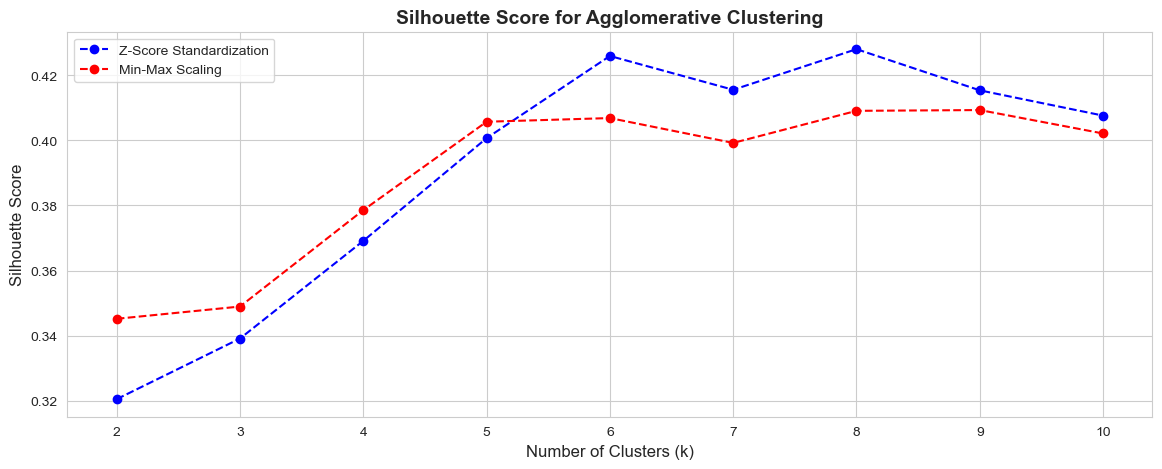

In [142]:
# ----------- Defining Range Of K-Cluster ----------- #
k_values = range(2, 11)

# ---------- Initiate List To Store Results ----------- #
silhouette_scores_zscore, silhouette_scores_minmax = [], []
davies_bouldin_zscore, davies_bouldin_minmax = [], []
calinski_harabasz_zscore, calinski_harabasz_minmax = [], []

# ------------ Defining Datasets For Comparison ----------- #
datasets = {'Z-Score Standardization': df_zscore, 'Min-Max Scaling': df_minmax}

# ------------- Performing Agglomerative Clustering ----------- #
for k in k_values:
    for scaling_method, df in datasets.items():
        # Apply Agglomerative Clustering #
        agg_clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
        df['Cluster'] = agg_clustering.fit_predict(df[features_to_scale])

        # Computing Clustering Evaluation Metrics #
        silhouette_avg = silhouette_score(df[features_to_scale], df['Cluster'])
        davies_bouldin = davies_bouldin_score(df[features_to_scale], df['Cluster'])
        calinski_harabasz = calinski_harabasz_score(df[features_to_scale], df['Cluster'])

        # Store Metrics in Respective Lists #
        if scaling_method == 'Z-Score Standardization':
            silhouette_scores_zscore.append(silhouette_avg)
            davies_bouldin_zscore.append(davies_bouldin)
            calinski_harabasz_zscore.append(calinski_harabasz)
        else:
            silhouette_scores_minmax.append(silhouette_avg)
            davies_bouldin_minmax.append(davies_bouldin)
            calinski_harabasz_minmax.append(calinski_harabasz)

# ----------- Plot Silhouette Score For Comparison ---------- #
plt.figure(figsize=(14, 5))
plt.plot(k_values, silhouette_scores_zscore, marker='o', linestyle='--', color='b', label="Z-Score Standardization")
plt.plot(k_values, silhouette_scores_minmax, marker='o', linestyle='--', color='r', label="Min-Max Scaling")

# ---------- Labels And Titles ----------- #
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Agglomerative Clustering', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)

# ---------- Displaying Plot ----------- #
plt.show()

<p>With reference to the output to the Line Plot for the Silhouette Score, for which I am able to see that the Min-Max has a lower Silhouette Score compared to Z-Score Standardisation. The observations and conclusion are listed below.</p>
<br/>
<p><strong><u>Min-Max Scaling</u></strong></p>
<ul>
    <li>Silhouette Score: Min-Max Scaling has a moderate Silhouette Score, peaking at around 0.42 for 6 Clusters.</li>
</ul>
<p><strong><u>Z-Score Standardisation</u></strong></p>
<ul>
    <li>Silhouette Score: Z-Score Standardisation has a higher Silhouette Score, peaking around 0.4 for 6 Clusters.</li>
</ul>
<p><strong><u>Conclusion</u></strong></p>
<ul>
    <li>Scaling Method To Use: Z-Score Standardisation.</li>
    <li>Reason: Performed better in Silhouette Score than Min-Max Scaling.</li>
</ul>
<p>With the observation and conclusion listed out, I will proceed to find the Optimal K-Clusters and Compare the PCA results with the Original Data.</p>

<hr/>
<h3>6.2.2 Finding Optimal K-Clusters And Reducing Dimensions</h3>

<p>Although Agglomerative Clustering does not require a k-cluser to be predefined, I will still be utilising the Sillhouette Score to find the Optimal k. The computation for the Sillhouette Score are indcated below. I will also be using Principal Component Analysis to reduce the dimensions of the Data to compare the results and determine if it improves the Silhouette Score. The formula for PCA is also indicated below.</p>
<br/>

$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

**Where:**  
- $S(i)$ → Silhouette Score of point $i$  
- $a(i)$ → Average distance between point $i$ and other points in the same cluster  
- $b(i)$ → Average distance between point $i$ and the nearest neighboring cluster  
- $-1 \leq S(i) \leq 1$, where:  
  - $S(i)$ close to **1** → Well clustered  
  - $S(i)$ close to **0** → Overlapping clusters  
  - $S(i)$ close to **-1** → Incorrect clustering

$$
Z = X W
$$

**Where:**
- $ Z $ is the transformed data in the new principal component space.  
- $ X $ is the original data matrix (centered by subtracting the mean).  
- $ W $ is the matrix of eigenvectors (principal components).  

$$
C = \frac{1}{n} X^T X
$$

**Where:**
- $ C $ is the covariance matrix of $ X $.  
- $ n $ is the number of samples.  

$$
C W = \lambda W
$$

**Where:**
- $ \lambda $ are the eigenvalues.  
- $ W $ are the corresponding eigenvectors (principal components).  
<br/>
<p>With the formulas listed, I will proceed to plot the Line Graph and conduct PCA in the cell below so as to identify the optimal K-Cluster.</p>

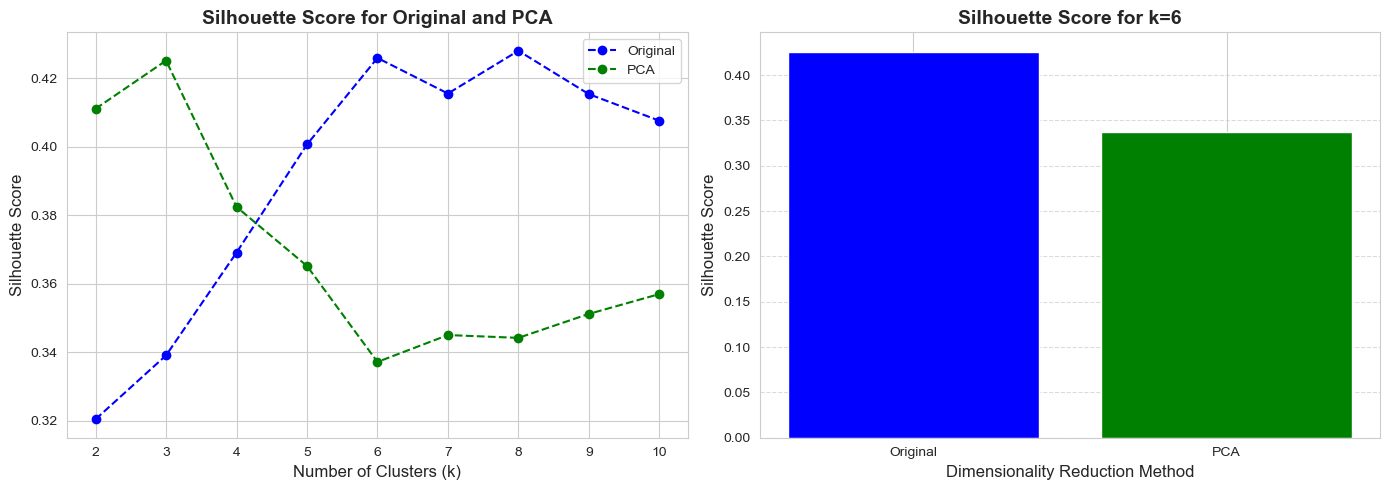

In [146]:
# ----------- Defining Range Of K-Clusters ----------- #
k_values = range(2, 11)

# ----------- Applying PCA ----------- #
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore[features_to_scale])

# ----------- Initiating List To Store Silhouettes Score ----------- #
silhouette_scores_original = []
silhouette_scores_pca = []

# ----------- Computing Clustering Metrics ----------- #
for k in k_values:
    # Agglomerative Clustering On Original Data #
    ac_original = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels_original = ac_original.fit_predict(df_zscore[features_to_scale])
    silhouette_scores_original.append(silhouette_score(df_zscore[features_to_scale], cluster_labels_original))

    # Agglomerative Clustering On PCA Data #
    ac_pca = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels_pca = ac_pca.fit_predict(pca_result)
    silhouette_scores_pca.append(silhouette_score(pca_result, cluster_labels_pca))

# ----------- Defining Subplots ----------- #
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------- Plotting Silhouette Scores Line Graph ----------- #
axes[0].plot(k_values, silhouette_scores_original, marker='o', linestyle='--', color='blue', label="Original")
axes[0].plot(k_values, silhouette_scores_pca, marker='o', linestyle='--', color='green', label="PCA")
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score for Original and PCA', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True)

# ----------- Plotting Bar Plot For Best K-Cluster ----------- #
best_k = 6
axes[1].bar(['Original', 'PCA'], [silhouette_scores_original[best_k-2], silhouette_scores_pca[best_k-2]], color=['blue', 'green'])
axes[1].set_xlabel('Dimensionality Reduction Method', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(f'Silhouette Score for k={best_k}', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# ----------- Displaying Plot ----------- #
plt.tight_layout()
plt.show()

<p>With reference to the output of the Line Graph showing the Silhouette Score for the Optimal k, I am able to come to the conclusion that the Optimal K is 6. The observation for each of the method respectively have been indicated below.</p>
<br/>
<p><strong><u>Sihouette Method</u></strong></p>
<ul>
    <li>At k = 6, the Silhoutte Score peaked the highest at around 0.42.</li>
</ul>
<p><strong><u>Dimension Reduction</u></strong></p>
<ul>
    <li>Use Orginal Data due to higher Silhouette Score.</li>
</ul>
<br/>
<p>Therefore, with the observations laid out and the ideal cluster of 6 determined, I will proceed to clustering using Agglomerative Clustering.</p>

<hr/>
<h3>6.2.3 Conducting Agglomerative Clustering And Plotting Dendrogram</h3>

<p>After determining the Optimal K-Clusters, I will proceed to conduct the clustering using the Agglomerative Clustering in the cell below and subsequently plot out the Dendrogram to see where we cut off for the 6 Clusters. The Dendrogram will be plotted using Euclidean Distance for which the formula is listed below.</p>

The Euclidean distance between two points in an **n-dimensional space** is given by:

$$ d(A, B) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2} $$

Where:

- $ d(A, B) $ is the Euclidean distance between points $ A $ and $ B $.  
- $ A_i, B_i $ are the coordinates of the points in **n-dimensional space**.  
- $ n $ is the number of dimensions.  

For **2D space**, the formula simplifies to:

$$ d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} $$

For **3D space**, the formula extends to:

$$ d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2} $$

**Interpretation**:  
- The smaller the distance, the closer the points are to each other.  
- It is widely used in clustering, nearest neighbor searches, and distance-based algorithms.
<br/>
<p>With the formula listed, I will proceed to conduct the clustering in the cell below.</p>

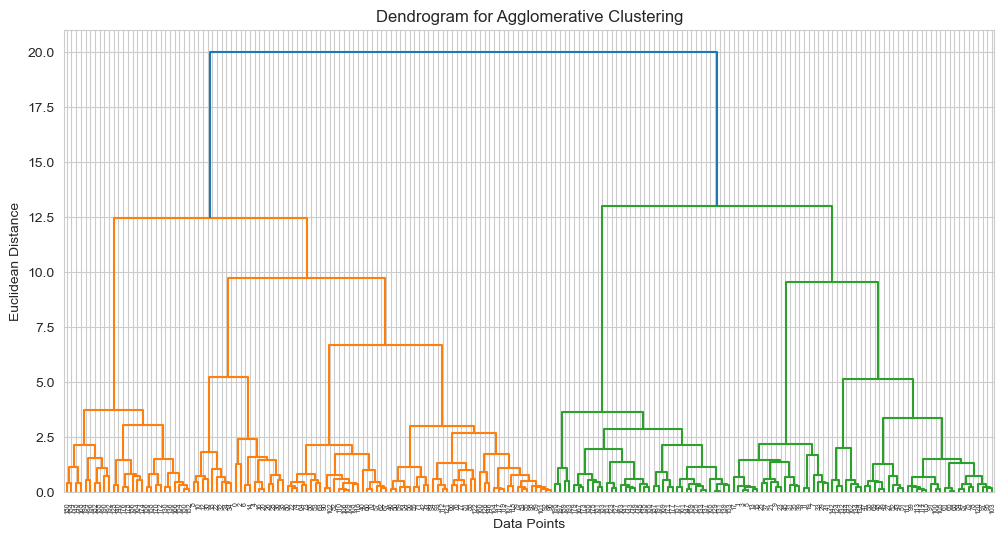

In [150]:
# ---------- Defining Optimal K-Clusters ----------- #
optimal_k = 6

# ----------- Applying Agglomerative Clustering ----------- #
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df_zscore['Cluster'] = agg_clustering.fit_predict(df_zscore[features_to_scale])

# ----------- Plot Dendrogram ----------- #
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(df_zscore[features_to_scale], method='ward'))

# ----------- Titles And Labels ----------- #
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.grid(True)

# ----------- Displaying Plot ----------- #
plt.show()

<p>With reference to the output of the Dendrogram above, I am able to see that for the k-cluster of 6, we cut off the Dendrogram at around 5.5. This is an ideal distance as seen from the Dendrogram as the distance was getting shorter and shorter after 5.5.</p>

<hr/>
<h3>6.2.4 Visualising Clusters Using t-SNE</h3>

<p>After finding the Optimal k-Cluster, I will proceed to visualise the Clusters by reducing the Dimensions using t-SNE and subsequently using a Scatterplot to viusalise the 6 Clusters. t-SNE allows us to reduce the dimensions into 2 dimensions to allow for a better visualisation. The formula for t-SNE is indicated below.</p>

The probability distribution in high-dimensional space is defined as:

$$ P_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)} $$

Where:

- $ P_{j|i} $ is the conditional probability that point $ x_j $ is chosen as a neighbor of point $ x_i $.  
- $ x_i, x_j $ are high-dimensional data points.  
- $ \sigma_i $ is the bandwidth of the Gaussian kernel for point $ x_i $.  

The probability distribution in low-dimensional space is:

$$ Q_{j|i} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq i} (1 + ||y_i - y_k||^2)^{-1}} $$

Where:

- $ Q_{j|i} $ is the conditional probability in the lower-dimensional space.  
- $ y_i, y_j $ are the mapped points in the lower-dimensional space.  

The Kullback-Leibler (KL) divergence, which t-SNE minimizes, is given by:

$$ KL(P||Q) = \sum_i \sum_j P_{ij} \log \frac{P_{ij}}{Q_{ij}} $$

Where:

- $ KL(P||Q) $ measures the difference between the high-dimensional and low-dimensional distributions.  
- $ P_{ij} $ and $ Q_{ij} 
- $ are the symmetric joint probabilities.  

<br/>
<p>With the formula indicated, I will proceed to conduct the visualisation in the cell below.</p>

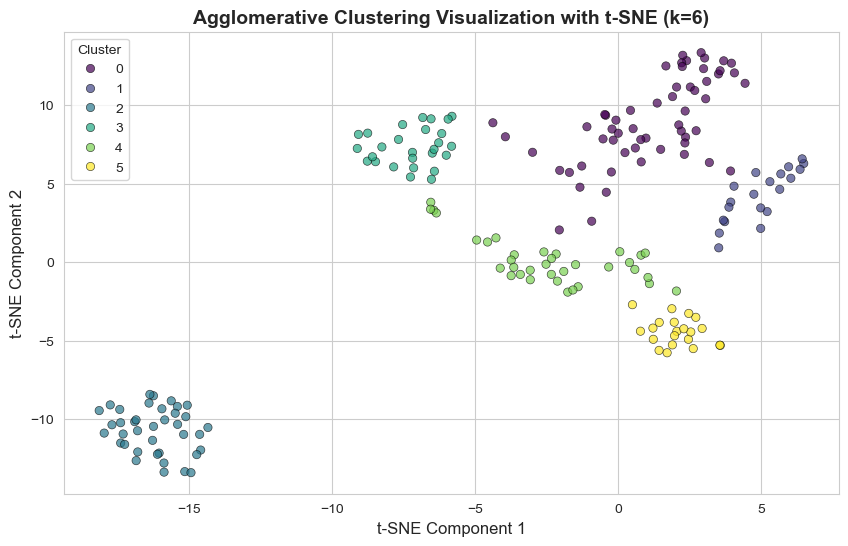

In [154]:
# ---------- Defining Optimal K-Clusters ----------- #
optimal_k = 6

# ----------- Computing Clustering evaluation Metrics ------------ #
silhouette_avg = silhouette_score(df_zscore[features_to_scale], df_zscore['Cluster'])
davies_bouldin = davies_bouldin_score(df_zscore[features_to_scale], df_zscore['Cluster'])
calinski_harabasz = calinski_harabasz_score(df_zscore[features_to_scale], df_zscore['Cluster'])

# ------------- Storing Results In DataFrame ----------- #
clustering_metrics = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Score', 'Calinski-Harabasz Score'],
    'Value': [silhouette_avg, davies_bouldin, calinski_harabasz]
})

# -------------- Applying t-SNE For Visualisation ------------- #
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
tsne_results = tsne.fit_transform(df_zscore[features_to_scale])

# ------------ Adding t-SNE Results Into DataFrame ------------ #
df_zscore['TSNE1'] = tsne_results[:, 0]
df_zscore['TSNE2'] = tsne_results[:, 1]

# ------------ Visualising t-SNE Clusters ------------ #
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_zscore['TSNE1'], y=df_zscore['TSNE2'], hue=df_zscore['Cluster'], 
                palette='viridis', alpha=0.7, edgecolor='black')

# ------------ Title And Labels ------------ #
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title(f'Agglomerative Clustering Visualization with t-SNE (k={optimal_k})', fontsize=14, fontweight='bold')
plt.legend(title="Cluster")
plt.grid(True)

# ------------ Displaying Plot ------------ #
plt.show()

<p>With reference to the output of the Visualisation of Clusters above, I am able to observe that the clusters are generally well-clustered with multiple exceptions. I will proceed to test out the other method of clustering and conduct cross referencing on the quality of clustering.</p>

<hr/>
<h3>6.2.5 Model Improvement For Agglomerative Clustering</h3>

<p>In this sub-section, I will be tuning the hyperparameter of Agglomerative Clustering so as to ensure the highest Silhouette Score is achieved. The metrics that will be used to evaluate the best parameters are Silhouette Score, Davies Bouldin Score and Calinski Harabasz Score in their respective order with Silhouette Score given priority. The formula for each of the metrics are listed below.</p>

---

#### **Silhouette Score Formula**

The silhouette score for a data point is given by:

$$ S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} $$

Where:

- $ S(i) $ is the silhouette score of point $ i $.  
- $ a(i) $ is the average distance between point $ i $ and other points in the same cluster.  
- $ b(i) $ is the average distance between point $ i $ and the nearest neighboring cluster.  

Interpretation:  
- $ S(i) \approx 1 $ → Well clustered  
- $ S(i) \approx 0 $ → Overlapping clusters  
- $ S(i) \approx -1 $ → Incorrect clustering  

---

#### **Davies-Bouldin (DB) Score Formula**

The Davies-Bouldin index is given by:

$$ DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d_{ij}} \right) $$

Where:

- $ k $ is the number of clusters.  
- $ \sigma_i $ is the average distance of all points in cluster $ i $ to the cluster centroid.  
- $ d_{ij} $ is the Euclidean distance between centroids of clusters $ i $ and $ j $.  

Interpretation:  
- Lower **DB score** means better clustering (lower intra-cluster distance, higher inter-cluster separation).  

---

#### **Calinski-Harabasz (CH) Score Formula**

The Calinski-Harabasz index is given by:

$$ CH = \frac{Tr(B_k)}{Tr(W_k)} \times \frac{n - k}{k - 1} $$

Where:

- $ Tr(B_k) $ is the trace of the between-cluster scatter matrix.  
- $ Tr(W_k) $ is the trace of the within-cluster scatter matrix.  
- $ n $ is the total number of samples.  
- $ k $ is the number of clusters.  

Interpretation:  
- Higher **CH score** means better clustering (higher inter-cluster separation and compactness within clusters).

---

<p>With the formula and metrics of evaluation indicated, I will proceed with hyperparameter tuning in the cell below.</p>

In [158]:
# ------------ Defining Of Parameters ----------- #
param_grid = {
    'n_clusters': [6],
    'linkage': ['ward', 'complete', 'average', 'single'],
    'distance_threshold': [None],
    'compute_full_tree': [True, False]
}

# ----------- Initiating Best Score And Best Parameters ----------- #
best_score = -1
best_params = {}

# ---------- Initiate List To Store Results ----------- #
results = []

# ------------ Performing Grid Search ----------- #
for params in ParameterGrid(param_grid):
    # Ensure 'ward' Linkage Does Not Require Distance #
    if params['linkage'] == 'ward':
        agg_clustering = AgglomerativeClustering(**params)
    else:
        agg_clustering = AgglomerativeClustering(**params, metric='euclidean')

    cluster_labels = agg_clustering.fit_predict(df_zscore[features_to_scale])
    
    # Computing Evaluation Metrics #
    silhouette_avg = silhouette_score(df_zscore[features_to_scale], cluster_labels)
    davies_bouldin = davies_bouldin_score(df_zscore[features_to_scale], cluster_labels)
    calinski_harabasz = calinski_harabasz_score(df_zscore[features_to_scale], cluster_labels)

    # Storing All Results #
    results.append({
        'n_clusters': params['n_clusters'],
        'linkage': params['linkage'],
        'compute_full_tree': params['compute_full_tree'],
        'silhouette_score': silhouette_avg,
        'davies_bouldin_score': davies_bouldin,
        'calinski_harabasz_score': calinski_harabasz
    })

    # Store Best Parameters Based On Silhouette Score #
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_params = params
        best_params['silhouette_score'] = silhouette_avg

# ----------- Converting Results To DataFrame ------------ #
results_df_ac = pd.DataFrame(results)

# ----------- Displaying DataFrame ----------- #
results_df_ac.sort_values(by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"], ascending=False).head(1).style.background_gradient(cmap="Blues")

,n_clusters,linkage,compute_full_tree,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,6,ward,True,0.425948,0.844619,124.891588


<p>With reference to the output of the DataFrame above, I am able to see that with the hyperparameter tuning, the Silhouette Score increase by a slight margin. The scoring metrics indicated here will be used for evaluation as comparison to all the other models.</p>

<hr/>
<h2>6.3 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)</h2>

<p>DBSCAN is a density-based clustering algorithm that groups data points based on density. It also works best with arbitrary-shaped clusters. I have listed the strengths and weaknesses of DBSCAN below.</p>
<br/>
<span style="color:green"><p><strong><u>Strengths</u></strong></p></span>
<ul>
    <li>K Do Not Need To Be Predefined</li>
    <li>Handles Arbitrary Shaped Clusters</li>
    <li>Able To Handle Data With Varying Densities</li>
</ul>
<span style="color:red"><p><strong><u>Weaknesses</u></strong></p></span>
<ul>
    <li>Extremely Sensitive To Parameters</li>
    <li>Fails For Varying Density Clusters</li>
    <li>Difficult Interpretation</li>
</ul>
<br/>
<p>With the context of the Strengths and Weaknesses of DBSCAN in mind, I will proceed to find the optimal EPS in the next sub-section.</p>

<hr/>
<h3>6.3.1 Deciding Best Scaling For DBSCAN</h3>

<p>I conducted 2 methods of Scaling previously which are the Z-Score Standardisation and the Min-Max Scaling. These 2 methods utilised different methods of adjusting the Numerical Value which was stated previosuly. I will be comparing the Silhouette Score of the Min-Max Scaling Data and the Z-Score Standardisation Data. The formula for Silhouette Score have been indicated below.</p> 

$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

**Where:**  
- $S(i)$ → Silhouette Score of point $i$  
- $a(i)$ → Average distance between point $i$ and other points in the same cluster  
- $b(i)$ → Average distance between point $i$ and the nearest neighboring cluster  
- $-1 \leq S(i) \leq 1$, where:  
  - $S(i)$ close to **1** → Well clustered  
  - $S(i)$ close to **0** → Overlapping clusters  
  - $S(i)$ close to **-1** → Incorrect clustering
 
<br/>
<p>With the formula listed, I will proceed to plot out the Graphs to identify the Best Scaling Method to use for DBSCAN.</p>

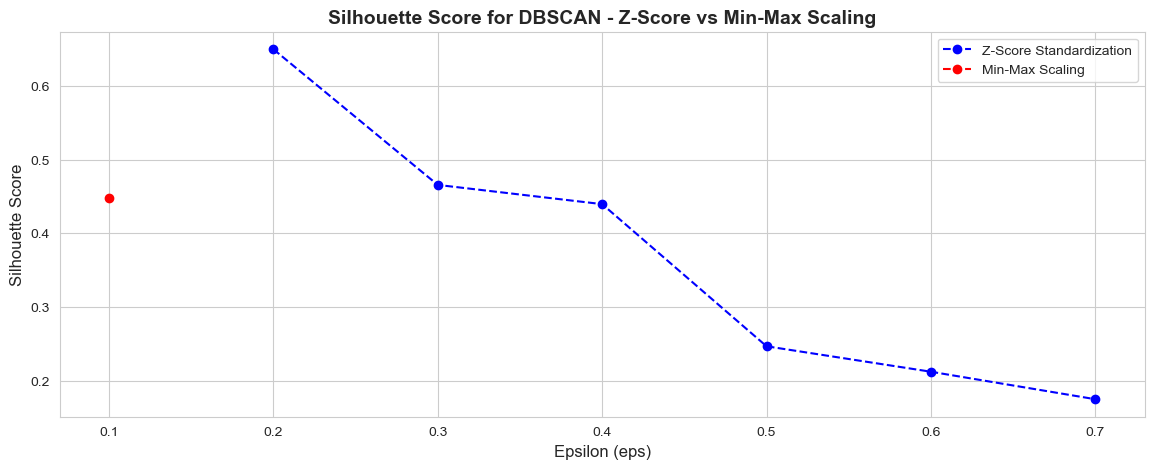

In [164]:
# ---------- Defining Range Of ESP Values ----------- #
eps_values = np.arange(0.1, 1.1, 0.1)

# ---------- Initiate List To Store Results ----------- #
silhouette_scores_zscore = []
silhouette_scores_minmax = []

# ------------ Defining Datasets For Comparison ----------- #
datasets = {'Z-Score Standardization': df_zscore.copy(), 'Min-Max Scaling': df_minmax.copy()}

# ------------ Performing DBSCAN ----------- #
for eps in eps_values:
    for scaling_method, df in datasets.items():
        # Applying DBSCAN #
        dbscan = DBSCAN(eps=eps, min_samples=3, metric='euclidean')
        df['Cluster'] = dbscan.fit_predict(df[features_to_scale])

        # Removing Noise Points (-1) Before Evaluation #
        filtered_df = df[df['Cluster'] != -1]
        if len(set(filtered_df['Cluster'])) > 1:
            silhouette_avg = silhouette_score(filtered_df[features_to_scale], filtered_df['Cluster'])
        else:
            silhouette_avg = np.nan

        # Store Metrics In Respective List #
        if scaling_method == 'Z-Score Standardization':
            silhouette_scores_zscore.append(silhouette_avg)
        else:
            silhouette_scores_minmax.append(silhouette_avg)

# ----------- Putting Results Into DataFrame ---------- #
silhouette_df = pd.DataFrame({
    'eps': eps_values,
    'Silhouette_ZScore': silhouette_scores_zscore,
    'Silhouette_MinMax': silhouette_scores_minmax
})

# ------------ Plotting Line Graph For DBSCAN ----------- #
plt.figure(figsize=(14, 5))
plt.plot(silhouette_df['eps'], silhouette_df['Silhouette_ZScore'], marker='o', linestyle='--', color='b', label="Z-Score Standardization")
plt.plot(silhouette_df['eps'], silhouette_df['Silhouette_MinMax'], marker='o', linestyle='--', color='r', label="Min-Max Scaling")

# ------------ Titles And Labels ----------- #
plt.xlabel('Epsilon (eps)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for DBSCAN - Z-Score vs Min-Max Scaling', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)

# ------------ Displaying Plot ----------- #
plt.show()

<p>With reference to the output to the Line Plot for the Silhouette Score, for which I am able to see that the Min-Max has a lower Silhouette Score compared to Z-Score Standardisation. The observations and conclusion are listed below.</p>
<br/>
<p><strong><u>Min-Max Scaling</u></strong></p>
<ul>
    <li>Silhouette Score: Min-Max Scaling has a moderate Silhouette Score, at around 0.45 at 0.1 Epsilon but afterwards being voided.</li>
</ul>
<p><strong><u>Z-Score Standardisation</u></strong></p>
<ul>
    <li>Silhouette Score: Min-Max Scaling has a moderate Consistent Silhouette Score, at around 0.25 at 0.5 Epsilon.</li>
</ul>
<p><strong><u>Conclusion</u></strong></p>
<ul>
    <li>Scaling Method To Use: Z-Score Standardisation.</li>
    <li>Reason: Performed better in Silhouette Score than Min-Max Scaling.</li>
</ul>
<p>With the observation and conclusion listed out, I will proceed to find the Optimal K-Clusters and Compare the PCA results with the Original Data.</p>

<hr/>
<h3>6.3.2 Finding Optimal Episilon And Reducing Dimensions</h3>

<p>Although DBSCAN does not require a k-cluser to be predefined, I will still be utilising the Sillhouette Score to find the Optimal Episilon. The computation for the Sillhouette Score are indcated below. I will also be using Principal Component Analysis to reduce the dimensions of the Data to compare the results and determine if it improves the Silhouette Score. The formula for PCA is also indicated below.</p>
<br/>

$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

**Where:**  
- $S(i)$ → Silhouette Score of point $i$  
- $a(i)$ → Average distance between point $i$ and other points in the same cluster  
- $b(i)$ → Average distance between point $i$ and the nearest neighboring cluster  
- $-1 \leq S(i) \leq 1$, where:  
  - $S(i)$ close to **1** → Well clustered  
  - $S(i)$ close to **0** → Overlapping clusters  
  - $S(i)$ close to **-1** → Incorrect clustering

$$
Z = X W
$$

**Where:**
- $ Z $ is the transformed data in the new principal component space.  
- $ X $ is the original data matrix (centered by subtracting the mean).  
- $ W $ is the matrix of eigenvectors (principal components).  

$$
C = \frac{1}{n} X^T X
$$

**Where:**
- $ C $ is the covariance matrix of $ X $.  
- $ n $ is the number of samples.  

$$
C W = \lambda W
$$

**Where:**
- $ \lambda $ are the eigenvalues.  
- $ W $ are the corresponding eigenvectors (principal components).  
<br/>
<p>With the formulas listed, I will proceed to plot the Line Graph and conduct PCA in the cell below so as to identify the optimal Epsilon.</p>

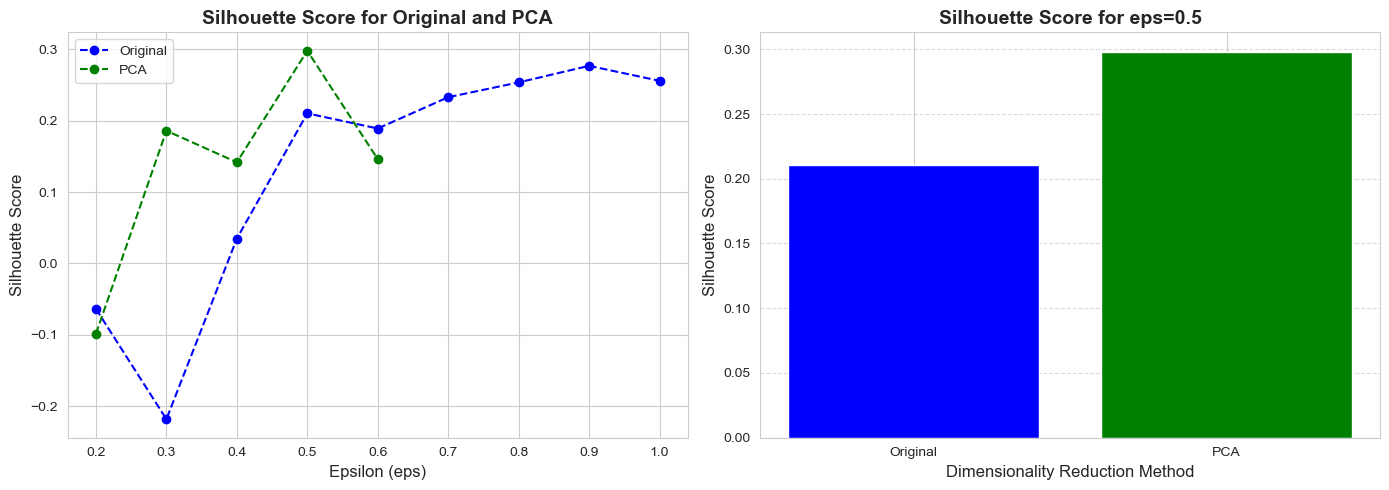

In [168]:
# ------------ Defining Range Of EPS Values ---------- #
eps_values = np.arange(0.1, 1.1, 0.1)

# ----------- Applying PCA ----------- #
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore[features_to_scale])

# ----------- Initiating List To Store Results ------------ #
silhouette_scores_original = []
silhouette_scores_pca = []

# ------------ Computing Clustering Metrics ----------- #
for eps in eps_values:
    # DBSCAN On Original Data #
    dbscan_original = DBSCAN(eps=eps, min_samples=5, metric='euclidean')
    cluster_labels_original = dbscan_original.fit_predict(df_zscore[features_to_scale])
    if len(set(cluster_labels_original)) > 1:
        silhouette_scores_original.append(silhouette_score(df_zscore[features_to_scale], cluster_labels_original))
    else:
        silhouette_scores_original.append(np.nan)

    # DBSCAN On PCA Data #
    dbscan_pca = DBSCAN(eps=eps, min_samples=5, metric='euclidean')
    cluster_labels_pca = dbscan_pca.fit_predict(pca_result)
    if len(set(cluster_labels_pca)) > 1:
        silhouette_scores_pca.append(silhouette_score(pca_result, cluster_labels_pca))
    else:
        silhouette_scores_pca.append(np.nan)

# ----------- Defining Subplots ----------- #
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- Plotting Line Graph For Silhouette Score ----------- #
axes[0].plot(eps_values, silhouette_scores_original, marker='o', linestyle='--', color='blue', label="Original")
axes[0].plot(eps_values, silhouette_scores_pca, marker='o', linestyle='--', color='green', label="PCA")
axes[0].set_xlabel('Epsilon (eps)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score for Original and PCA', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True)

# ------------ Plotting Bar Plot For Best ESP Score ----------- #
best_eps = 0.5
axes[1].bar(['Original', 'PCA'], [silhouette_scores_original[int(best_eps * 10 - 1)], silhouette_scores_pca[int(best_eps * 10 - 1)]], color=['blue', 'green'])
axes[1].set_xlabel('Dimensionality Reduction Method', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(f'Silhouette Score for eps={best_eps}', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# ----------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

<p>With reference to the output of the Line Graph showing the Silhouette Score for the Optimal Epsilon, I am able to come to the conclusion that the Optimal Epsilon is 0.9. The observation for each of the method respectively have been indicated below.</p>
<br/>
<p><strong><u>Sihouette Method</u></strong></p>
<ul>
    <li>At eps = 0.9, the Silhoutte Score peaked at around 0.28.</li>
</ul>
<p><strong><u>Dimension Reduction</u></strong></p>
<ul>
    <li>Use Orginal Data due to no Consistency in PCA Data.</li>
</ul>
<br/>
<p>Therefore, with the observations laid out and the ideal epsilon of 0.9 is determined, I will proceed to clustering using DBSCAN.</p>

<hr/>
<h3>6.3.3 Visualising Clusters Using t-SNE</h3>

<p>After finding the Optimal Epsilon, I will proceed to visualise the Clusters by reducing the Dimensions using t-SNE and subsequently using a Scatterplot to viusalise the Clustering at 0.9 Epsilon. t-SNE allows us to reduce the dimensions into 2 dimensions to allow for a better visualisation. The formula for t-SNE is indicated below.</p>

The probability distribution in high-dimensional space is defined as:

$$ P_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)} $$

Where:

- $ P_{j|i} $ is the conditional probability that point $ x_j $ is chosen as a neighbor of point $ x_i $.  
- $ x_i, x_j $ are high-dimensional data points.  
- $ \sigma_i $ is the bandwidth of the Gaussian kernel for point $ x_i $.  

The probability distribution in low-dimensional space is:

$$ Q_{j|i} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq i} (1 + ||y_i - y_k||^2)^{-1}} $$

Where:

- $ Q_{j|i} $ is the conditional probability in the lower-dimensional space.  
- $ y_i, y_j $ are the mapped points in the lower-dimensional space.  

The Kullback-Leibler (KL) divergence, which t-SNE minimizes, is given by:

$$ KL(P||Q) = \sum_i \sum_j P_{ij} \log \frac{P_{ij}}{Q_{ij}} $$

Where:

- $ KL(P||Q) $ measures the difference between the high-dimensional and low-dimensional distributions.  
- $ P_{ij} $ and $ Q_{ij} 
- $ are the symmetric joint probabilities.  

<br/>
<p>With the formula indicated, I will proceed to conduct the visualisation in the cell below.</p>

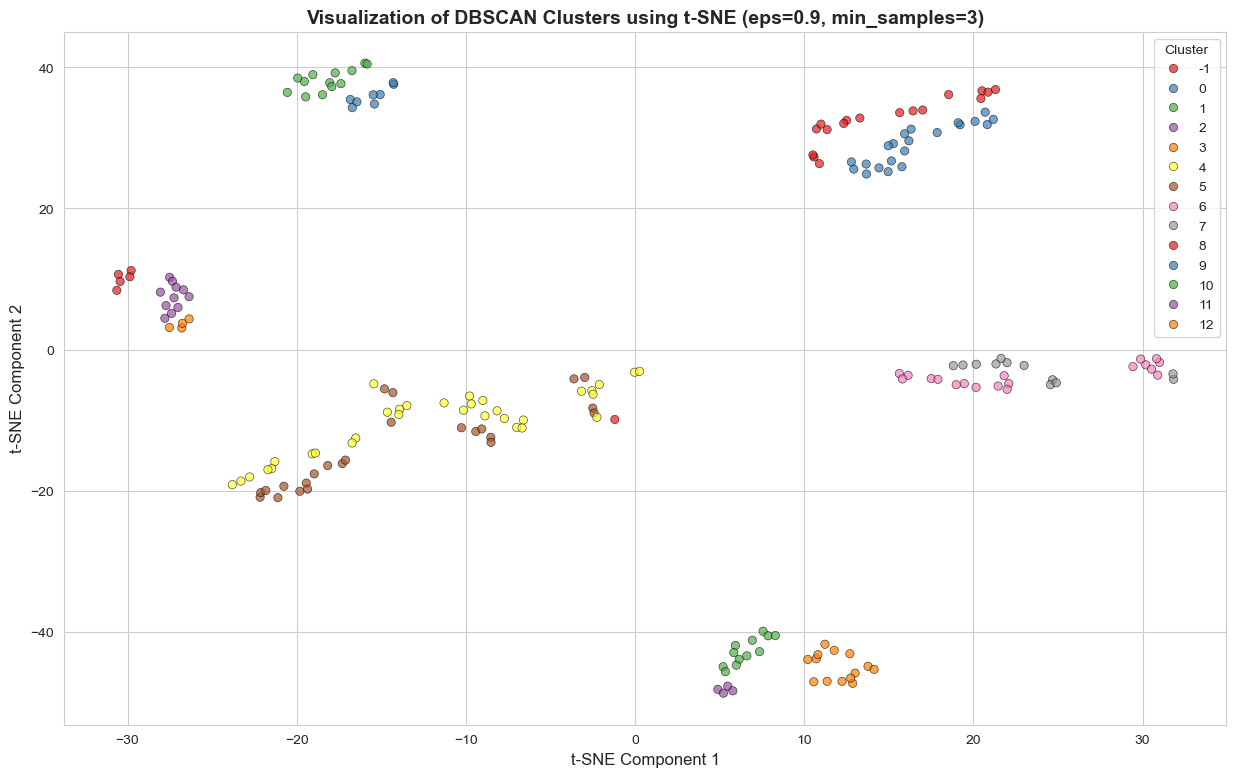

In [172]:
# ---------- Define Optimal Episilon ----------- #
optimal_eps = 0.9
min_samples = 3

# ---------- Applying DBSCAN On Data ----------- #
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples, metric='euclidean')
df_zscore['Cluster'] = dbscan.fit_predict(df_zscore.drop(columns=['TSNE1', 'TSNE2'], errors='ignore'))

# -------------- Applying t-SNE For Visualisation ------------- #
tsne = TSNE(n_components=2, random_state=42, perplexity=10, learning_rate=50)
tsne_results = tsne.fit_transform(df_zscore)

# ------------ Adding t-SNE Results Into DataFrame ------------ #
df_zscore['TSNE1'] = tsne_results[:, 0]
df_zscore['TSNE2'] = tsne_results[:, 1]

# ------------ Visualising t-SNE Clusters ------------ #
plt.figure(figsize=(15, 9))
sns.scatterplot(x=df_zscore['TSNE1'], y=df_zscore['TSNE2'], hue=df_zscore['Cluster'],
                palette='Set1', alpha=0.7, edgecolor='black')

# ------------ Title And Labels ------------ #
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title(f'Visualization of DBSCAN Clusters using t-SNE (eps={optimal_eps}, min_samples={min_samples})',
          fontsize=14, fontweight='bold')
plt.legend(title="Cluster")
plt.grid(True)

# ------------ Displaying Plot ------------- #
plt.show()

<p>With reference to the output of the Visualisation of Clusters above, I am able to observe that the clusters are poorly clustered with a very minimal amount exceptions. I will proceed to test out the other method of clustering and conduct cross referencing on the quality of clustering.</p>

<hr/>
<h3>6.3.4 Model Improvement For DBSCAN</h3>

<p>In this sub-section, I will be tuning the hyperparameter of DBSCAN so as to ensure the highest Silhouette Score is achieved. The metrics that will be used to evaluate the best parameters are Silhouette Score, Davies Bouldin Score and Calinski Harabasz Score in their respective order with Silhouette Score given priority. The formula for each of the metrics are listed below.</p>

---

#### **Silhouette Score Formula**

The silhouette score for a data point is given by:

$$ S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} $$

Where:

- $ S(i) $ is the silhouette score of point $ i $.  
- $ a(i) $ is the average distance between point $ i $ and other points in the same cluster.  
- $ b(i) $ is the average distance between point $ i $ and the nearest neighboring cluster.  

Interpretation:  
- $ S(i) \approx 1 $ → Well clustered  
- $ S(i) \approx 0 $ → Overlapping clusters  
- $ S(i) \approx -1 $ → Incorrect clustering  

---

#### **Davies-Bouldin (DB) Score Formula**

The Davies-Bouldin index is given by:

$$ DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d_{ij}} \right) $$

Where:

- $ k $ is the number of clusters.  
- $ \sigma_i $ is the average distance of all points in cluster $ i $ to the cluster centroid.  
- $ d_{ij} $ is the Euclidean distance between centroids of clusters $ i $ and $ j $.  

Interpretation:  
- Lower **DB score** means better clustering (lower intra-cluster distance, higher inter-cluster separation).  

---

#### **Calinski-Harabasz (CH) Score Formula**

The Calinski-Harabasz index is given by:

$$ CH = \frac{Tr(B_k)}{Tr(W_k)} \times \frac{n - k}{k - 1} $$

Where:

- $ Tr(B_k) $ is the trace of the between-cluster scatter matrix.  
- $ Tr(W_k) $ is the trace of the within-cluster scatter matrix.  
- $ n $ is the total number of samples.  
- $ k $ is the number of clusters.  

Interpretation:  
- Higher **CH score** means better clustering (higher inter-cluster separation and compactness within clusters).

---

<p>With the formula and metrics of evaluation indicated, I will proceed with hyperparameter tuning in the cell below.</p>

In [176]:
# ------------ Defining Parameter For Tuning ---------- #
param_grid = {
    'eps': [0.9],
    'min_samples': [3, 5, 7, 10],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# ------------ Initialising Best Parameter And Score ----------- #
best_score = -1
best_params = {}

# ------------ Initiating List For Results Storage ----------- #
results = []

# ----------- Perform Grid Search For DBSCAN ----------- #
for params in ParameterGrid(param_grid):
    dbscan = DBSCAN(**params)
    cluster_labels = dbscan.fit_predict(df_zscore[features_to_scale])
    
    # Remove Noise Points #
    filtered_df = df_zscore[cluster_labels != -1]
    if len(set(filtered_df['Cluster'])) > 1:  # Ensure at least 2 clusters exist
        silhouette_avg = silhouette_score(filtered_df[features_to_scale], filtered_df['Cluster'])
        davies_bouldin = davies_bouldin_score(filtered_df[features_to_scale], filtered_df['Cluster'])
        calinski_harabasz = calinski_harabasz_score(filtered_df[features_to_scale], filtered_df['Cluster'])
    else:
        silhouette_avg, davies_bouldin, calinski_harabasz = np.nan, np.nan, np.nan

    # Store All Results #
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'metric': params['metric'],
        'algorithm': params['algorithm'],
        'silhouette_score': silhouette_avg,
        'davies_bouldin_score': davies_bouldin,
        'calinski_harabasz_score': calinski_harabasz
    })

    # Storing Best Parameter Based On Silhouette Score #
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_params = params
        best_params['silhouette_score'] = silhouette_avg

# ------------ Convert Results To DataFrame ------------ #
results_df_dbscan = pd.DataFrame(results)

# ------------ Displaying DataFrame ------------ #
results_df_dbscan.sort_values(by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"], ascending=False).head(1).style.background_gradient(cmap="Blues")

,eps,min_samples,metric,algorithm,silhouette_score,davies_bouldin_score,calinski_harabasz_score
2,0.900000,7,euclidean,auto,0.012085,4.275562,56.064419


<p>With reference to the output of the DataFrame above, I am able to see that with the hyperparameter tuning, the Silhouette Score increase by a slight margin. The scoring metrics indicated here will be used for evaluation as comparison to all the other models.</p>

<hr/>
<h2>6.4 Model Comparison And Evaluation</h2>

<p>In this sub-section, I will be comparing the 3 different models that I have used and choose the best performing model to adopt and interpret. I will be comparing the metrics after the Hyperparameter tuning for each of the model. Subsequently, I will save the model and interpret the clustering so as to ensure that the model is beneficial to the stakeholder.</p>

<hr/>
<h3>6.4.1 Identifying Best Model</h3>

<p>In this sub-section, I will be indentifying the best model amongst all the 3 models that I have tested. The best model is defined by having the highest Silhouette Score, Lowest Davies Bouldin Score and Highest Calinski Harabasz Score. The Best Model will then be used to visualise the Clustering another time before the saving of the model and subsequently, the interpretation of the clustering and its implications.</p>

In [182]:
# ----------- Extracting Best Results ----------- #
best_kmeans = results_df_kmeans.sort_values(
    by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"], 
    ascending=False
).head(1)[["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"]]

best_ac = results_df_ac.sort_values(
    by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"], 
    ascending=False
).head(1)[["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"]]

best_dbscan = results_df_dbscan.sort_values(
    by=["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"], 
    ascending=False
).head(1)[["silhouette_score", "davies_bouldin_score", "calinski_harabasz_score"]]

# ----------- Assigning Method As Index ------------ #
best_kmeans.index = ["K-Means"]
best_ac.index = ["Agglomerative Clustering"]
best_dbscan.index = ["DBSCAN"]

# ----------- Combining All Data Rows ---------- #
final_results_df = pd.concat([best_kmeans, best_ac, best_dbscan])

# ------------ Displaying DataFrame ----------- #
final_results_df.style.background_gradient(cmap="Blues")

,silhouette_score,davies_bouldin_score,calinski_harabasz_score
K-Means,0.436898,0.821283,138.307770
Agglomerative Clustering,0.425948,0.844619,124.891588
DBSCAN,0.012085,4.275562,56.064419


<p>With reference to the output of the DataFrame above, I am able to confirm that the model that is determined to be the best model is K-Means. This is due to it having the highest Silhouette Score, the lowest Davies Bouldin Score and the highest Calinski Harabasz Score. Therefore, I will proceed to utilise the K-Means Clustering Model for the interpretation.</p>

<hr/>
<h3>6.4.2 Visualising Best Model Clustering</h3>

<p>With K-Means determined to be the best model, I will proceed to visualise the clustering quality of K-Means and determine if the clustering quality is satisfactory or should the hyperparameter be tuned further.</p>

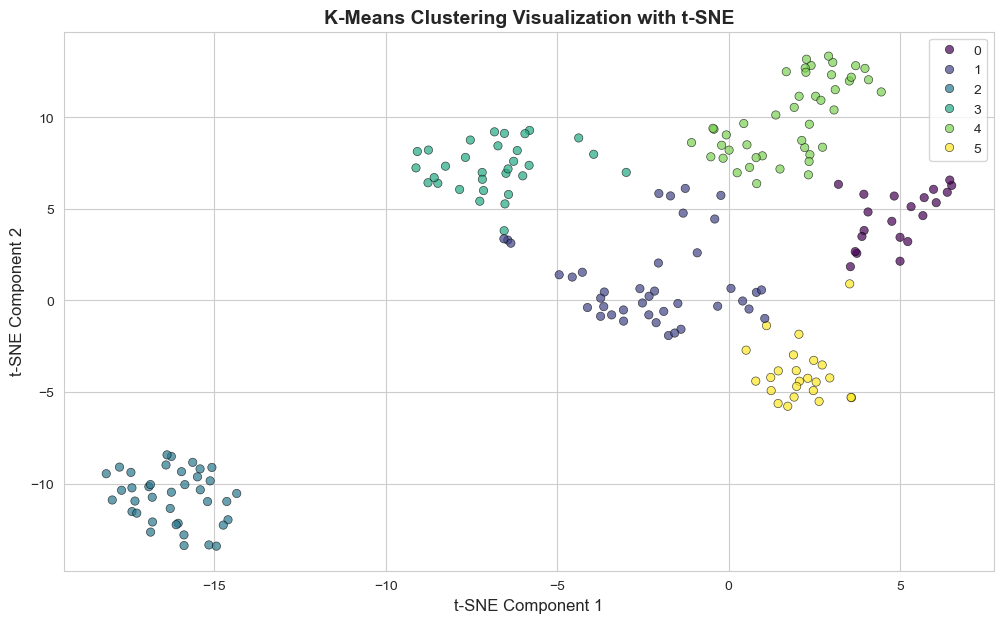

In [186]:
# ------------ Define Parameters For K-Means ------------ #
kmeans = KMeans(
    n_clusters=6,
    init='random',
    max_iter=100,
    n_init=10,
    algorithm='lloyd',
    random_state=42
)

# ------------ Fit K-Means To Data ------------ #
df_zscore['Cluster'] = kmeans.fit_predict(df_zscore[features_to_scale])

# -------------- Applying t-SNE For Visualisation ------------- #
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
tsne_results = tsne.fit_transform(df_zscore[features_to_scale])
df_zscore['TSNE1'] = tsne_results[:, 0]
df_zscore['TSNE2'] = tsne_results[:, 1]

# ----------- Visualise Clusters ----------- #
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=df_zscore['TSNE1'], y=df_zscore['TSNE2'], 
    hue=df_zscore['Cluster'], palette='viridis', alpha=0.7, edgecolor='black'
)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('K-Means Clustering Visualisation with t-SNE', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

<p>With reference to the Clustering Visualisation above, I am able to see that generally, the clustering conducted by K-Means is satisfactory with a few exceptions. However, these exceptions are minimal, therefore, we are able to accept K-Means as our primary model.</p>

<hr/>
<h3>6.4.3 Saving Of K-Means Model</h3>

<p>In this sub-section, I will be saving the K-Means Model and its parameter so as to prepare it for deployment and be used for clustering with other data.</p>

In [190]:
# ---------- Saving Of Model ---------- #
os.makedirs('../models', exist_ok=True)
joblib.dump(kmeans, '../models/kmeans_model.pkl')

# ---------- Confirmation Message ----------- #
print("Model Saved Successfully")

Model Saved Successfully


<p>With reference to the confirmation message above, I am able to determined that the K-Means have been saved successfully and is ready for deployment.</p>